In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load the cleaned master table we saved yesterday
master = pd.read_parquet('../data/processed/master_delivered.parquet')

print(f"Loaded: {master.shape[0]:,} rows, {master.shape[1]} columns")
print(f"Date range: {master['order_purchase_timestamp'].min().date()} to {master['order_purchase_timestamp'].max().date()}")
print(f"Unique customers: {master['customer_unique_id'].nunique():,}")

Loaded: 110,197 rows, 22 columns
Date range: 2016-09-15 to 2018-08-29
Unique customers: 93,358


In [2]:
# Collapse to one row per order, with customer_unique_id
orders_per_customer = (
    master
    .groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp'], as_index=False)
    .agg(order_value=('price', 'sum'))
)

print(f"Rows in master:              {len(master):,}")
print(f"Unique orders:               {orders_per_customer['order_id'].nunique():,}")
print(f"Orders table shape:          {orders_per_customer.shape}")

# Quick peek
orders_per_customer.head()

Rows in master:              110,197
Unique orders:               96,478
Orders table shape:          (96478, 4)


,order_id,customer_unique_id,order_purchase_timestamp,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,58.90
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,239.90
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,199.00
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,199.90


In [3]:
# Step A: Find each customer's first purchase date
first_purchase = (
    orders_per_customer
    .groupby('customer_unique_id', as_index=False)
    .agg(first_purchase_date=('order_purchase_timestamp', 'min'))
)

# Step B: Create the cohort label (year-month of first purchase)
first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M').dt.to_timestamp()

print("Cohort assignments for first 5 customers:")
print(first_purchase.head())

print(f"\nCohort distribution (customers per cohort):")
cohort_sizes = first_purchase['cohort_month'].value_counts().sort_index()
print(cohort_sizes)

Cohort assignments for first 5 customers:
                 customer_unique_id first_purchase_date cohort_month
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27   2018-05-01
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27   2018-05-01
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03   2017-03-01
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41   2017-10-01
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42   2017-11-01

Cohort distribution (customers per cohort):
cohort_month
2016-09-01       1
2016-10-01     262
2016-12-01       1
2017-01-01     717
2017-02-01    1628
2017-03-01    2503
2017-04-01    2256
2017-05-01    3451
2017-06-01    3037
2017-07-01    3752
2017-08-01    4057
2017-09-01    4004
2017-10-01    4328
2017-11-01    7060
2017-12-01    5338
2018-01-01    6842
2018-02-01    6288
2018-03-01    6774
2018-04-01    6582
2018-05-01    6506
2018-06-01    5878
2018-07-01    5949
2018-08-01    6144
Name: count, dtype: int64


In [4]:
# Join first_purchase info back to orders
orders_with_cohort = orders_per_customer.merge(first_purchase, on='customer_unique_id', how='left')

# Calculate order_month (which month did this specific order happen)
orders_with_cohort['order_month'] = (
    orders_with_cohort['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
)

# Calculate month index: 0 = same month as first purchase, 1 = next month, etc.
orders_with_cohort['month_index'] = (
    (orders_with_cohort['order_month'].dt.year - orders_with_cohort['cohort_month'].dt.year) * 12
    + (orders_with_cohort['order_month'].dt.month - orders_with_cohort['cohort_month'].dt.month)
)

print("Sample of orders with cohort info:")
print(orders_with_cohort[['customer_unique_id', 'order_purchase_timestamp', 'cohort_month', 'order_month', 'month_index']].head(10))

print(f"\nMonth index distribution:")
print(orders_with_cohort['month_index'].value_counts().sort_index().head(15))

Sample of orders with cohort info:
                 customer_unique_id order_purchase_timestamp cohort_month  \
0  871766c5855e863f6eccc05f988b23cb      2017-09-13 08:59:02   2017-09-01   
1  eb28e67c4c0b83846050ddfb8a35d051      2017-04-26 10:53:06   2017-04-01   
2  3818d81c6709e39d06b2738a8d3a2474      2018-01-14 14:33:31   2018-01-01   
3  af861d436cfc08b2c2ddefd0ba074622      2018-08-08 10:00:35   2018-08-01   
4  64b576fb70d441e8f1b2d7d446e483c5      2017-02-04 13:57:51   2017-02-01   
5  85c835d128beae5b4ce8602c491bf385      2017-05-15 21:42:34   2017-05-01   
6  635d9ac1680f03288e72ada3a1035803      2017-12-10 11:53:48   2017-12-01   
7  fda4476abb6307ab3c415b7e6d026526      2018-07-04 12:08:27   2018-07-01   
8  639d23421f5517f69d0c3d6e6564cf0e      2018-03-19 18:40:33   2018-03-01   
9  0782c41380992a5a533489063df0eef6      2018-07-02 13:59:39   2018-07-01   

  order_month  month_index  
0  2017-09-01            0  
1  2017-04-01            0  
2  2018-01-01            0  
3

In [5]:
# Count unique customers per (cohort, month_index) combination
cohort_data = (
    orders_with_cohort
    .groupby(['cohort_month', 'month_index'])['customer_unique_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_unique_id': 'active_customers'})
)

# Pivot to get the matrix: rows = cohort, columns = month_index
cohort_counts = cohort_data.pivot(
    index='cohort_month',
    columns='month_index',
    values='active_customers'
)

# Show the raw count matrix (absolute customer counts)
print("Cohort counts (absolute customers):")
print(cohort_counts.head(10))

Cohort counts (absolute customers):
month_index       0     1     2     3     4     5     6    7    8     9    10  \
cohort_month                                                                    
2016-09-01       1.0   NaN   NaN   NaN   NaN   NaN   NaN  NaN  NaN   NaN  NaN   
2016-10-01     262.0   NaN   NaN   NaN   NaN   NaN   1.0  NaN  NaN   1.0  NaN   
2016-12-01       1.0   1.0   NaN   NaN   NaN   NaN   NaN  NaN  NaN   NaN  NaN   
2017-01-01     717.0   2.0   2.0   1.0   3.0   1.0   3.0  1.0  1.0   NaN  3.0   
2017-02-01    1628.0   3.0   5.0   2.0   7.0   2.0   4.0  3.0  2.0   3.0  2.0   
2017-03-01    2503.0  11.0   9.0  10.0   9.0   4.0   4.0  8.0  8.0   2.0  9.0   
2017-04-01    2256.0  14.0   5.0   4.0   6.0   6.0   8.0  7.0  7.0   4.0  6.0   
2017-05-01    3451.0  16.0  16.0  10.0  10.0  11.0  14.0  5.0  9.0   9.0  9.0   
2017-06-01    3037.0  15.0  12.0  13.0   9.0  12.0  11.0  7.0  4.0   6.0  9.0   
2017-07-01    3752.0  20.0  13.0   9.0  11.0   8.0  12.0  4.0  7.0  10.0 

In [6]:
# Each cohort's starting size = the month 0 count
cohort_sizes = cohort_counts[0]

# Divide every column by the cohort's starting size to get retention %
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0) * 100

print("Retention matrix (% of original cohort still active):")
print(retention_matrix.head(12).round(2))

Retention matrix (% of original cohort still active):
month_index      0       1     2     3     4     5     6     7     8     9   \
cohort_month                                                                  
2016-09-01    100.0     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2016-10-01    100.0     NaN   NaN   NaN   NaN   NaN  0.38   NaN   NaN  0.38   
2016-12-01    100.0  100.00   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2017-01-01    100.0    0.28  0.28  0.14  0.42  0.14  0.42  0.14  0.14   NaN   
2017-02-01    100.0    0.18  0.31  0.12  0.43  0.12  0.25  0.18  0.12  0.18   
2017-03-01    100.0    0.44  0.36  0.40  0.36  0.16  0.16  0.32  0.32  0.08   
2017-04-01    100.0    0.62  0.22  0.18  0.27  0.27  0.35  0.31  0.31  0.18   
2017-05-01    100.0    0.46  0.46  0.29  0.29  0.32  0.41  0.14  0.26  0.26   
2017-06-01    100.0    0.49  0.40  0.43  0.30  0.40  0.36  0.23  0.13  0.20   
2017-07-01    100.0    0.53  0.35  0.24  0.29  0.21  0.32  0.11  0.19  0.27  

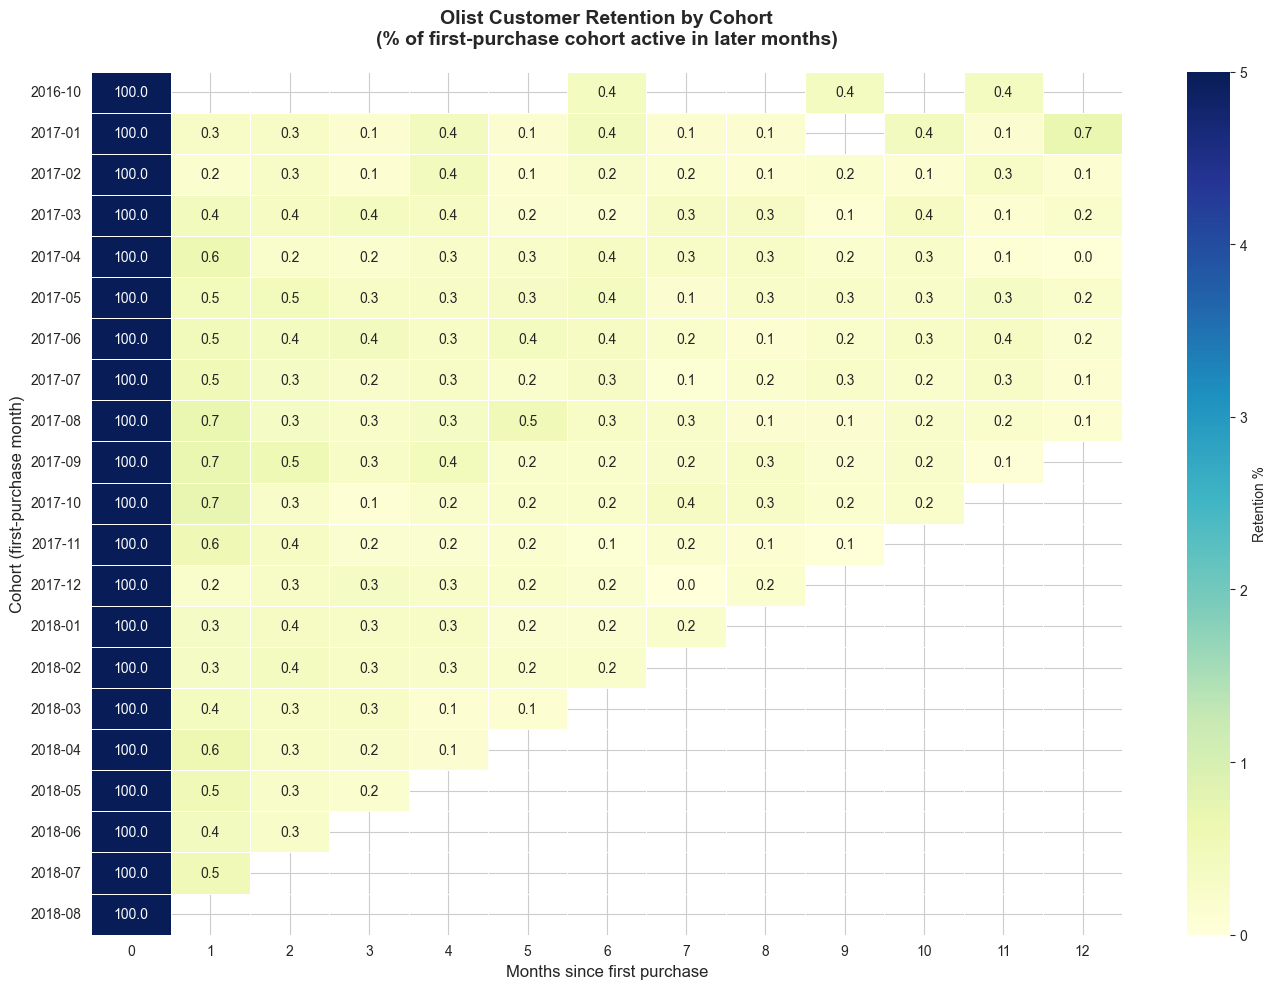


Heatmap saved to reports/cohort_retention_heatmap.png


In [7]:
# Filter out tiny noise cohorts (Sept 2016 = 1 customer, Dec 2016 = 1 customer)
retention_filtered = retention_matrix[cohort_sizes >= 50].copy()

# Only show first 13 months for readability
retention_filtered = retention_filtered.iloc[:, :13]

# Format cohort labels as "YYYY-MM" strings for nicer axis
retention_filtered.index = retention_filtered.index.strftime('%Y-%m')

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    retention_filtered,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0,
    vmax=5,
    cbar_kws={'label': 'Retention %'},
    linewidths=0.5,
    linecolor='white'
)
plt.title('Olist Customer Retention by Cohort\n(% of first-purchase cohort active in later months)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Months since first purchase', fontsize=12)
plt.ylabel('Cohort (first-purchase month)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHeatmap saved to reports/cohort_retention_heatmap.png")

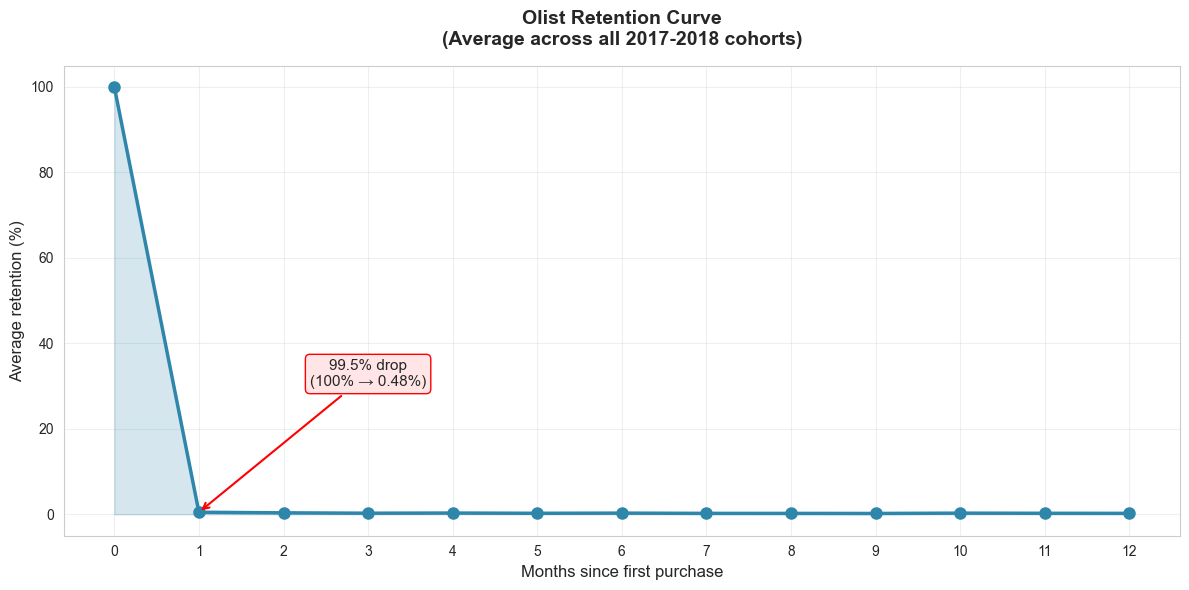


Average retention by month:
month_index
0     100.00
1       0.48
2       0.34
3       0.25
4       0.29
5       0.23
6       0.27
7       0.21
8       0.21
9       0.19
10      0.26
11      0.23
12      0.21
dtype: float64


In [8]:
# Exclude tiny/incomplete cohorts, keep first 13 months
valid_cohorts = retention_matrix[cohort_sizes >= 100].iloc[:, :13]

# Calculate the AVERAGE retention across all cohorts for each month_index
avg_retention = valid_cohorts.mean(axis=0)

# Plot: average retention curve
plt.figure(figsize=(12, 6))
plt.plot(avg_retention.index, avg_retention.values,
         marker='o', linewidth=2.5, color='#2E86AB', markersize=8)
plt.fill_between(avg_retention.index, 0, avg_retention.values, alpha=0.2, color='#2E86AB')

# Annotate the cliff
plt.annotate(
    f'99.5% drop\n(100% → {avg_retention[1]:.2f}%)',
    xy=(1, avg_retention[1]),
    xytext=(3, 30),
    fontsize=11,
    ha='center',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    bbox=dict(boxstyle='round', facecolor='#FFE5E5', edgecolor='red')
)

plt.title('Olist Retention Curve\n(Average across all 2017-2018 cohorts)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months since first purchase', fontsize=12)
plt.ylabel('Average retention (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 13))
plt.tight_layout()
plt.savefig('../reports/retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage retention by month:")
print(avg_retention.round(2))

In [9]:
# Define our analysis snapshot (one day after the last purchase in the data)
snapshot_date = orders_per_customer['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date (our 'today'): {snapshot_date}")

# Build the RFM table: one row per customer with R, F, M
rfm = (
    orders_per_customer
    .groupby('customer_unique_id')
    .agg(
        last_purchase=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('order_value', 'sum')
    )
    .reset_index()
)

# Calculate recency in days from snapshot date
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# Clean up and inspect
rfm = rfm[['customer_unique_id', 'recency', 'frequency', 'monetary']]
print(f"\nRFM table shape: {rfm.shape}")
print("\nDescriptive stats:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

print("\nSample rows:")
print(rfm.head())

Snapshot date (our 'today'): 2018-08-30 15:00:37

RFM table shape: (93358, 4)

Descriptive stats:
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    141.62
std      152.59       0.21    215.69
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      219.00       1.00     89.73
75%      346.00       1.00    154.74
max      714.00      15.00  13440.00

Sample rows:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
2  0000f46a3911fa3c0805444483337064      537          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00


In [10]:
# Score Recency: lower recency (more recent) = higher score
# qcut divides into 5 equal-size groups
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Score Monetary: higher spend = higher score
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score Frequency: special handling because ~99% of customers have freq=1
# Standard qcut fails here. We manually assign:
def frequency_score(freq):
    if freq == 1:
        return 1
    elif freq == 2:
        return 3
    elif freq <= 4:
        return 4
    else:
        return 5

rfm['F_score'] = rfm['frequency'].apply(frequency_score)

# Combine into an RFM segment code
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print("RFM scores assigned:")
print(rfm.head(10))

print("\nScore distributions:")
print("\nR_score distribution:")
print(rfm['R_score'].value_counts().sort_index())
print("\nF_score distribution:")
print(rfm['F_score'].value_counts().sort_index())
print("\nM_score distribution:")
print(rfm['M_score'].value_counts().sort_index())

RFM scores assigned:
                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90        4   
2  0000f46a3911fa3c0805444483337064      537          1     69.00        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    154.00        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     27.99        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    382.00        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    135.00        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    104.90        4   

   M_score  F_score RFM_score  
0        4        1       414  
1        1        1       411  
2        2        1     

In [11]:
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    
    # Champions: bought recently + multiple times + spend well
    if r >= 4 and f >= 4:
        return 'Champions'
    
    # Loyal Customers: multiple purchases, decent recency
    if f >= 3 and r >= 3:
        return 'Loyal Customers'
    
    # Potential Loyalists: recent + at least 2 orders
    if r >= 4 and f == 3:
        return 'Potential Loyalists'
    
    # At Risk: used to buy multiple times but haven't recently
    if f >= 3 and r <= 2:
        return 'At Risk'
    
    # New Customers: just bought, first time, high spend
    if r == 5 and f == 1 and m >= 4:
        return 'New High-Value'
    
    # Recent One-Timers: just bought once, haven't come back yet (still hopeful)
    if r >= 4 and f == 1:
        return 'Recent One-Timers'
    
    # Hibernating: bought once, a while ago, low to mid spend
    if r <= 2 and f == 1 and m <= 3:
        return 'Lost / Hibernating'
    
    # Big Spenders Lost: bought once, high value, now gone
    if r <= 2 and f == 1 and m >= 4:
        return 'Lost High-Value'
    
    # Everyone else — middle-of-the-road one-timers
    return 'Middle One-Timers'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Segment counts
segment_counts = rfm['segment'].value_counts()
print("Customer segments:")
print(segment_counts)
print(f"\nTotal customers: {len(rfm):,}")

# What % of customers in each segment
print("\nSegment share:")
print((segment_counts / len(rfm) * 100).round(2))

Customer segments:
segment
Recent One-Timers     29103
Lost / Hibernating    22582
Middle One-Timers     18105
Lost High-Value       13646
New High-Value         7121
Loyal Customers        1691
At Risk                 988
Champions               122
Name: count, dtype: int64

Total customers: 93,358

Segment share:
segment
Recent One-Timers     31.17
Lost / Hibernating    24.19
Middle One-Timers     19.39
Lost High-Value       14.62
New High-Value         7.63
Loyal Customers        1.81
At Risk                1.06
Champions              0.13
Name: count, dtype: float64


In [12]:
# Calculate total spend per segment (this matters more than just counts)
segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        avg_monetary=('monetary', 'mean'),
        total_monetary=('monetary', 'sum'),
        avg_frequency=('frequency', 'mean'),
        avg_recency_days=('recency', 'mean')
    )
    .sort_values('total_monetary', ascending=False)
    .round(2)
)

print("Segment summary (sorted by total revenue contribution):")
print(segment_summary)

print(f"\nTotal customers across all segments: {segment_summary['customer_count'].sum():,}")
print(f"Total revenue across all segments:   R$ {segment_summary['total_monetary'].sum():,.2f}")

Segment summary (sorted by total revenue contribution):
                    customer_count  avg_monetary  total_monetary  \
segment                                                            
Lost High-Value              13646        278.15      3795588.68   
Recent One-Timers            29103        109.39      3183581.89   
Middle One-Timers            18105        129.79      2349882.66   
New High-Value                7121        266.73      1899383.41   
Lost / Hibernating           22582         56.00      1264652.72   
Loyal Customers               1691        253.11       428014.20   
At Risk                        988        246.51       243556.29   
Champions                      122        465.89        56838.26   

                    avg_frequency  avg_recency_days  
segment                                              
Lost High-Value              1.00            394.82  
Recent One-Timers            1.00            101.40  
Middle One-Timers            1.00            22

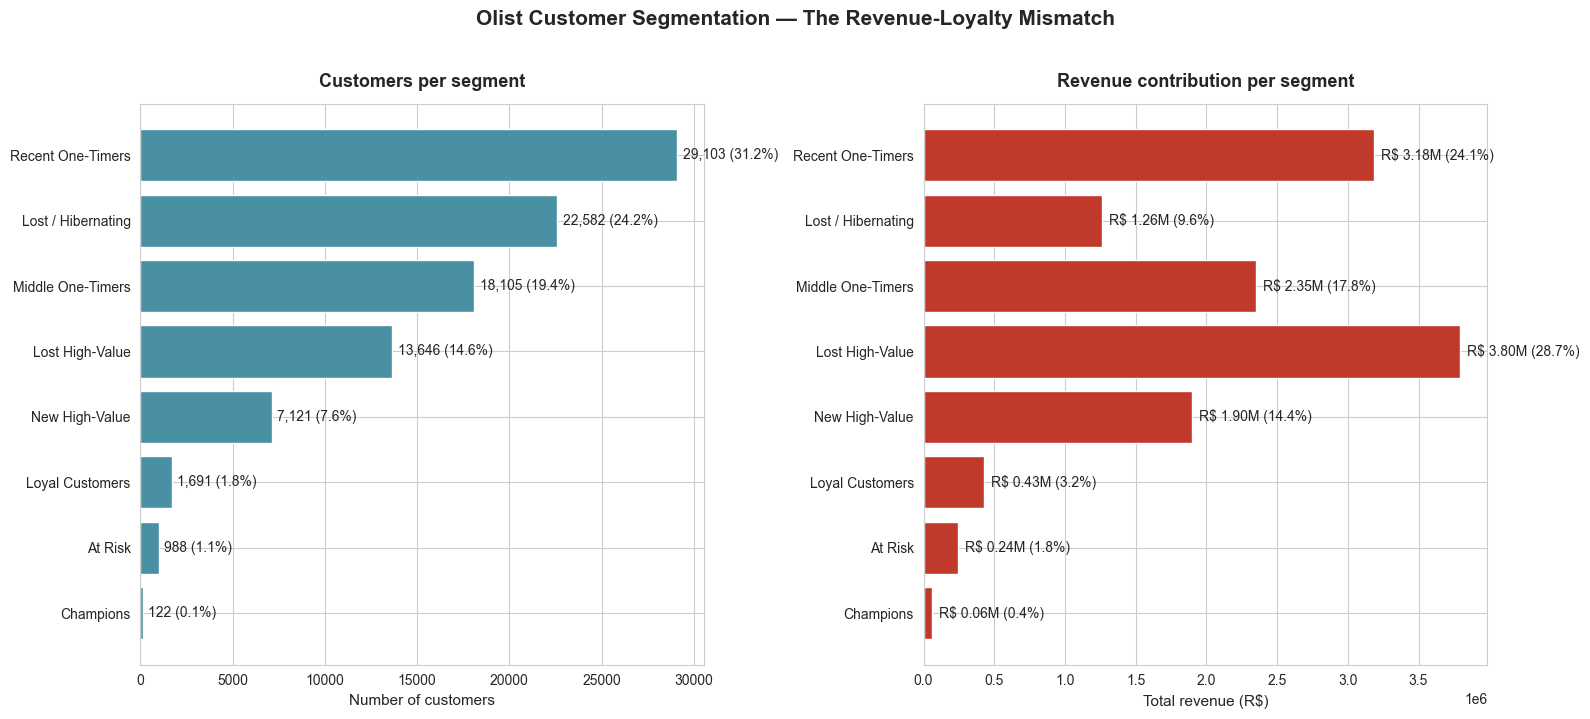

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sort segments by customer count for the left chart
segment_order = rfm['segment'].value_counts().index.tolist()

# ============ LEFT CHART: Customer count ============
counts = [segment_counts[s] for s in segment_order]
bars1 = axes[0].barh(segment_order, counts, color='#4A90A4', edgecolor='white')
axes[0].set_xlabel('Number of customers', fontsize=11)
axes[0].set_title('Customers per segment', fontsize=13, fontweight='bold', pad=12)
axes[0].invert_yaxis()

# Annotate bars with numbers and percentages
total = len(rfm)
for bar, count in zip(bars1, counts):
    pct = count / total * 100
    axes[0].text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
                 f'{count:,} ({pct:.1f}%)',
                 va='center', fontsize=10)

# ============ RIGHT CHART: Revenue per segment ============
revenue = [segment_summary.loc[s, 'total_monetary'] for s in segment_order]
bars2 = axes[1].barh(segment_order, revenue, color='#C0392B', edgecolor='white')
axes[1].set_xlabel('Total revenue (R$)', fontsize=11)
axes[1].set_title('Revenue contribution per segment', fontsize=13, fontweight='bold', pad=12)
axes[1].invert_yaxis()

# Annotate bars with revenue and percentage
total_rev = sum(revenue)
for bar, rev in zip(bars2, revenue):
    pct = rev / total_rev * 100
    axes[1].text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
                 f'R$ {rev/1e6:.2f}M ({pct:.1f}%)',
                 va='center', fontsize=10)

plt.suptitle('Olist Customer Segmentation — The Revenue-Loyalty Mismatch',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Save RFM segmentation for later use (SQL loading, dashboarding, etc.)
rfm.to_csv('../data/processed/rfm_segmentation.csv', index=False)
rfm.to_parquet('../data/processed/rfm_segmentation.parquet', index=False)

# Also save the segment summary
segment_summary.to_csv('../data/processed/segment_summary.csv')

print("Saved:")
print("  data/processed/rfm_segmentation.csv")
print("  data/processed/rfm_segmentation.parquet")
print("  data/processed/segment_summary.csv")
print(f"\nRFM table has {len(rfm):,} rows ready for use.")

Saved:
  data/processed/rfm_segmentation.csv
  data/processed/rfm_segmentation.parquet
  data/processed/segment_summary.csv

RFM table has 93,358 rows ready for use.
